In [1]:
# Import relevant packages
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy_financial as npf
from lcoe.lcoe import lcoe
from pathlib import Path
import os
from statsmodels.distributions.empirical_distribution import ECDF
import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.mixture import GaussianMixture
import contextily as cx

In [ ]:
# Read in the CSV files for PV annual energy production and PV system size for each block
pv_sizes_10pct = gpd.read_file('../data/processed/west-bengal-block-pv-10pct.geojson')
pv_energy_prod_10pct = pd.read_csv('../data/processed/block-pv-energy-lifetime-10pct.csv')

pv_sizes_30pct = gpd.read_file('../data/processed/west-bengal-block-pv-30pct.geojson')
pv_energy_prod_30pct = pd.read_csv('../data/processed/block-pv-energy-lifetime-30pct.csv')

pv_sizes_100pct = gpd.read_file('../data/processed/west-bengal-block-pv-100pct.geojson')
pv_energy_prod_100pct = pd.read_csv('../data/processed/block-pv-energy-lifetime-100pct.csv')

In [54]:
pv_energy_prod_10pct

,year,Bankura-I,Bankura-Ii,Barjora,Chhatna,Gangajal Ghati,Hirbandh,Indpur,Indus,Jaypur,...,Nagrakata,Rajganj,Binpur-I,Binpur-Ii,Gopiballav Pur -Ii,Gopiballavpur-I,Jambani,Jhargram,Nayagram,Sankrail-J
0,0,18193.598310,18193.598310,18193.598310,18193.598310,18193.598310,12129.065540,18193.598310,12129.065540,18193.598310,...,71314.806920,362395.651500,18568.187230,29399.629780,12378.791480,12378.791480,12378.791480,23210.234030,18568.187230,12378.791480
1,1,17738.758352,17738.758352,17738.758352,17738.758352,17738.758352,11825.838901,17738.758352,11825.838901,17738.758352,...,69531.936747,353335.760212,18103.982549,28664.639036,12069.321693,12069.321693,12069.321693,22629.978179,18103.982549,12069.321693
2,2,17618.134795,17618.134795,17618.134795,17618.134795,17618.134795,11745.423197,17618.134795,11745.423197,17618.134795,...,69059.119577,350933.077043,17980.875468,28469.719490,11987.250305,11987.250305,11987.250305,22476.094328,17980.875468,11987.250305
3,3,17498.331479,17498.331479,17498.331479,17498.331479,17498.331479,11665.554319,17498.331479,11665.554319,17498.331479,...,68589.517564,348546.732119,17858.605515,28276.125398,11905.737003,11905.737003,11905.737003,22323.256886,17858.605515,11905.737003
4,4,17379.342825,17379.342825,17379.342825,17379.342825,17379.342825,11586.228550,17379.342825,11586.228550,17379.342825,...,68123.108845,346176.614341,17737.166997,28083.847745,11824.777992,11824.777992,11824.777992,22171.458739,17737.166997,11824.777992
5,5,17261.163294,17261.163294,17261.163294,17261.163294,17261.163294,11507.442196,17261.163294,11507.442196,17261.163294,...,67659.871704,343822.613363,17616.554262,27892.877580,11744.369501,11744.369501,11744.369501,22020.692820,17616.554262,11744.369501
6,6,17143.787383,17143.787383,17143.787383,17143.787383,17143.787383,11429.191589,17143.787383,11429.191589,17143.787383,...,67199.784577,341484.619592,17496.761693,27703.206013,11664.507789,11664.507789,11664.507789,21870.952109,17496.761693,11664.507789
7,7,17027.209629,17027.209629,17027.209629,17027.209629,17027.209629,11351.473086,17027.209629,11351.473086,17027.209629,...,66742.826042,339162.524179,17377.783713,27514.824212,11585.189136,11585.189136,11585.189136,21722.229634,17377.783713,11585.189136
8,8,16911.424604,16911.424604,16911.424604,16911.424604,16911.424604,11274.283069,16911.424604,11274.283069,16911.424604,...,66288.974825,336856.219015,17259.614784,27327.723407,11506.409850,11506.409850,11506.409850,21574.518473,17259.614784,11506.409850
9,9,16796.426916,16796.426916,16796.426916,16796.426916,16796.426916,11197.617944,16796.426916,11197.617944,16796.426916,...,65838.209796,334565.596725,17142.249403,27141.894888,11428.166263,11428.166263,11428.166263,21427.811747,17142.249403,11428.166263


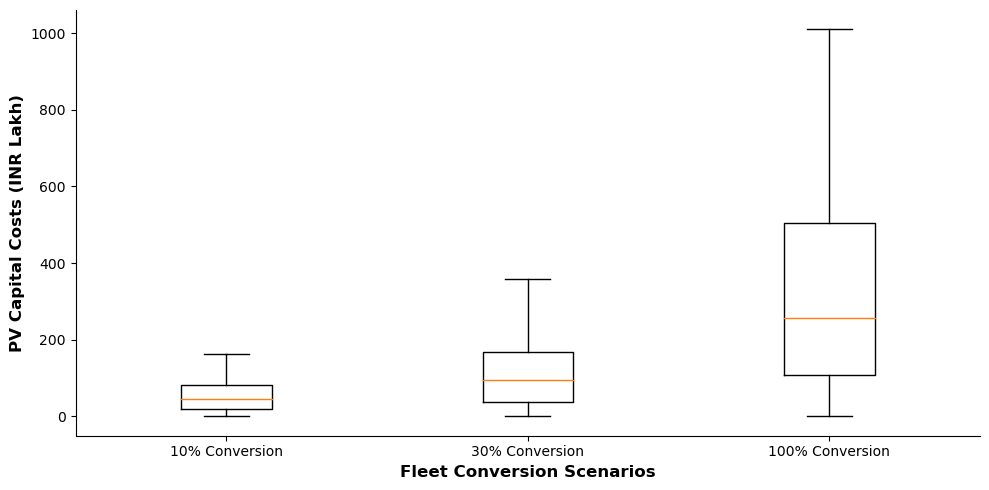

In [55]:
# Create a new dataframe containing the CAPEX costs for each block's PV size size
# Define the capital costs per kW
capex_cost = 1040           # $1,040/kW

# Create a copy of the dataframe and drop irrelevant columns
block_pv_cost_10pct = pv_sizes_10pct.copy().drop(columns={
    '10%_conversion_annual_pv_energy', 'geometry'
})
block_pv_cost_30pct = pv_sizes_30pct.copy().drop(columns={
    '30%_conversion_annual_pv_energy', 'geometry'
})
block_pv_cost_100pct = pv_sizes_100pct.copy().drop(columns={
    '100%_conversion_annual_pv_energy', 'geometry'
})

# Conversion rate
usd_to_inr = 85.57

# Add a new column calculating the capital costs for each system for each block
block_pv_cost_10pct['pv_capex_usd'] = block_pv_cost_10pct['10%_conversion_pv_size'] * capex_cost
block_pv_cost_10pct['pv_capex_inr_lakh'] = block_pv_cost_10pct['pv_capex_usd'] * usd_to_inr / 100000       # Convert to INR Lakh

block_pv_cost_30pct['pv_capex_usd'] = block_pv_cost_30pct['30%_conversion_pv_size'] * capex_cost
block_pv_cost_30pct['pv_capex_inr_lakh'] = block_pv_cost_30pct['pv_capex_usd'] * usd_to_inr / 100000       # Convert to INR Lakh

block_pv_cost_100pct['pv_capex_usd'] = block_pv_cost_100pct['100%_conversion_pv_size'] * capex_cost
block_pv_cost_100pct['pv_capex_inr_lakh'] = block_pv_cost_100pct['pv_capex_usd'] * usd_to_inr / 100000       # Convert to INR Lakh

# Plot a boxplot for how the CAPEX costs vary across the 10%, 30%, 100% fleet conversion scenarios
labels = ['10% Conversion', '30% Conversion', '100% Conversion']

fig, ax = plt.subplots(figsize=(10,5))
ax.boxplot(x=[block_pv_cost_10pct['pv_capex_inr_lakh'],
              block_pv_cost_30pct['pv_capex_inr_lakh'],
              block_pv_cost_100pct['pv_capex_inr_lakh']],
              labels=labels,
              showfliers=False)

# Customize the plot
ax.set_xlabel('Fleet Conversion Scenarios', fontsize=12, fontweight='bold')
ax.set_ylabel('PV Capital Costs (INR Lakh)', fontsize=12, fontweight='bold')

# Define the border around the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.tight_layout()
plt.show()

In [5]:
block_pv_cost_10pct['pv_capex_inr_lakh'].mean()

87.3986681043478

In [6]:
block_pv_cost_30pct['pv_capex_inr_lakh'].mean()

188.69569001739129

In [7]:
block_pv_cost_100pct['pv_capex_inr_lakh'].mean()

542.5181653101448

In [56]:
# Calculate the total investment cost to build all charging stations for each scenario
total_investment_10pct = block_pv_cost_10pct['pv_capex_inr_lakh'].sum()
total_investment_30pct = block_pv_cost_30pct['pv_capex_inr_lakh'].sum()
total_investment_100pct = block_pv_cost_100pct['pv_capex_inr_lakh'].sum()

# Print the results
print(f'Total Investment Cost for 10% Conversion Scenario: {total_investment_10pct:.2f}')
print(f'Total Investment Cost for 30% Conversion Scenario: {total_investment_30pct:.2f}')
print(f'Total Investment Cost for 100% Conversion Scenario: {total_investment_100pct:.2f}')

Total Investment Cost for 10% Conversion Scenario: 30152.54
Total Investment Cost for 30% Conversion Scenario: 65100.01
Total Investment Cost for 100% Conversion Scenario: 187168.77


In [ ]:
# Write out the CAPEX costs for each block's PV system per scenario
block_pv_cost_10pct.to_csv('../data/processed/block-pv-cost-10pct.csv', index=False)
block_pv_cost_30pct.to_csv('../data/processed/block-pv-cost-30pct.csv', index=False)
block_pv_cost_100pct.to_csv('../data/processed/block-pv-cost-100pct.csv', index=False)

In [ ]:
# Determine the block and **MINIMUM** PV size across all blocks
# 10% fleet conversion
min_idx_10pct = pv_sizes_10pct['10%_conversion_pv_size'].idxmin()
min_pv_size_10pct = pv_sizes_10pct.at[min_idx_10pct, '10%_conversion_pv_size']
min_pv_block_10pct = pv_sizes_10pct.at[min_idx_10pct, 'block']

# 30% fleet conversion
min_idx_30pct = pv_sizes_30pct['30%_conversion_pv_size'].idxmin()
min_pv_size_30pct = pv_sizes_30pct.at[min_idx_30pct, '30%_conversion_pv_size']
min_pv_block_30pct = pv_sizes_30pct.at[min_idx_30pct, 'block']

# 100% fleet conversion
min_idx_100pct = pv_sizes_100pct['100%_conversion_pv_size'].idxmin()
min_pv_size_100pct = pv_sizes_100pct.at[min_idx_100pct, '100%_conversion_pv_size']
min_pv_block_100pct = pv_sizes_100pct.at[min_idx_100pct, 'block']

# Determine the block and **MAXIMUM** PV size across all blocks
max_idx_10pct = pv_sizes_10pct['10%_conversion_pv_size'].idxmax()
max_pv_size_10pct = pv_sizes_10pct.at[max_idx_10pct, '10%_conversion_pv_size']
max_pv_block_10pct = pv_sizes_10pct.at[max_idx_10pct, 'block']

# 30% fleet conversion
max_idx_30pct = pv_sizes_30pct['30%_conversion_pv_size'].idxmax()
max_pv_size_30pct = pv_sizes_30pct.at[max_idx_30pct, '30%_conversion_pv_size']
max_pv_block_30pct = pv_sizes_30pct.at[max_idx_30pct, 'block']

# 100% fleet conversion
max_idx_100pct = pv_sizes_100pct['100%_conversion_pv_size'].idxmax()
max_pv_size_100pct = pv_sizes_100pct.at[max_idx_100pct, '100%_conversion_pv_size']
max_pv_block_100pct = pv_sizes_100pct.at[max_idx_100pct, 'block']

In [58]:
# Define a function to calculate the costs for each block based on the PV system size
def block_annual_costs(df_pv, fleet_conversion='10%_conversion'):

    # Unit costs for PV system
    capex_per_kw = 1040         # $1,040/kW
    opex_per_kw = 3.80          # $3.80/kW/year
    subsidy_percentage = 0.35   # 35% subsidy of fixed capital
    subsidy_cap = 40000000 / 85.57  # Subsidy capped at 40 Crore = INR 40,000,000

    # Create a dictionary to store the CAPEX and OPEX costs for PV system for each block
    block_pv_economics = {}

    # Extract the individual block names
    block_id = df_pv['block'].unique()

    # Initialize the lifespan of the PV system (i.e. 25 years)
    years = list(range(26))

    for block in block_id:
        block_pv_size = df_pv.loc[df_pv['block'] == block, f'{fleet_conversion}_pv_size'].values[0]

        # Initialize empty lists for storing the investment and O&M costs for each year of the PV system
        investment_cost = []
        o_and_m_cost = []
        subsidy = []

        # Loop over each year to calculate the costs
        for year in years:
            # Investment cost (only in year 0)
            if year == 0:
                investment_cost.append(capex_per_kw * block_pv_size)
            else:
                investment_cost.append(0)

            # O&M costs (from year 1 through year 25)
            if year >= 1:
                o_and_m_cost.append(opex_per_kw * block_pv_size)
            else:
                o_and_m_cost.append(0)

            # Subsidy (only for years 1 through 5, distributed evenly)
            # Calculate the total subsidy given the PV size capital cost
            total_subsidy = subsidy_percentage * capex_per_kw * block_pv_size
            if 1 <= year <= 5:
                # If the total subsidy exceeds the subsidy cap, only subsidize the investment cost based on the threshold
                if total_subsidy > subsidy_cap:
                    subsidy.append(subsidy_cap / 5)
                elif total_subsidy <= subsidy_cap:
                    subsidy.append(total_subsidy / 5)
            else:
                subsidy.append(0)

        # Create a DataFrame for each block with the calculated values
        block_economics_df = pd.DataFrame({
            'year': years,
            'investment_cost_$': investment_cost,
            'o&m_cost_$': o_and_m_cost,
            'subsidy_$': subsidy
        })

        # Store the DataFrame for each block in the dictionary
        block_pv_economics[block] = block_economics_df

    return block_pv_economics

In [59]:
# Calculate the lifetime capex and opex costs of the PV system per block
# Output is a dictionary with a dataframe for each block
pv_costs_10pct = block_annual_costs(pv_sizes_10pct, fleet_conversion='10%_conversion')
pv_costs_30pct = block_annual_costs(pv_sizes_30pct, fleet_conversion='30%_conversion')
pv_costs_100pct = block_annual_costs(pv_sizes_100pct, fleet_conversion='100%_conversion')

In [87]:
pv_costs_30pct['Kolkata']

,year,investment_cost_$,o&m_cost_$,subsidy_$
0,0,17313920,0.0,0.000000
1,1,0,63262.4,93490.709361
2,2,0,63262.4,93490.709361
3,3,0,63262.4,93490.709361
4,4,0,63262.4,93490.709361
5,5,0,63262.4,93490.709361
6,6,0,63262.4,0.000000
7,7,0,63262.4,0.000000
8,8,0,63262.4,0.000000
9,9,0,63262.4,0.000000


In [89]:
pv_costs_100pct['Kolkata']

,year,investment_cost_$,o&m_cost_$,subsidy_$
0,0,54918240,0.0,0.000000
1,1,0,200662.8,93490.709361
2,2,0,200662.8,93490.709361
3,3,0,200662.8,93490.709361
4,4,0,200662.8,93490.709361
5,5,0,200662.8,93490.709361
6,6,0,200662.8,0.000000
7,7,0,200662.8,0.000000
8,8,0,200662.8,0.000000
9,9,0,200662.8,0.000000


,observation_date,discount_rate
0,1968-01-01,6.00
1,1968-02-01,6.00
2,1968-03-01,5.00
3,1968-04-01,5.00
4,1968-05-01,5.00
...,...,...
650,2022-03-01,4.25
651,2022-04-01,4.25
652,2022-05-01,4.65
653,2022-06-01,5.15


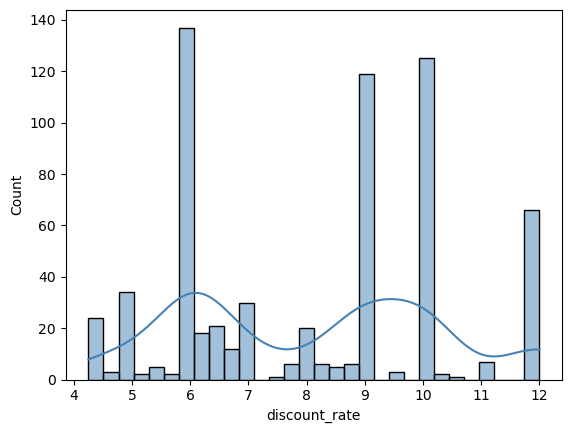

In [ ]:
# Read in the historical discount rate and create a histogram
historical_discount_rates = pd.read_csv('../data/raw/INTDSRINM193N.csv')

# Fix the year interpretation before converting date to datetime format
def fix_year(date_str):
    """Convert two-digit years: assume 1900s for >= 68, else 2000s."""
    parts = date_str.split('/')
    if len(parts) == 3:
        month, day, year = parts
        year = int(year)
        if year >= 68:
            year += 1900
        else:
            year += 2000
        return f"{month}/{day}/{year}"
    return date_str

# Apply the fix_year function
historical_discount_rates['observation_date'] = historical_discount_rates['observation_date'].apply(fix_year)

# Convert date column to datetiem format
historical_discount_rates['observation_date'] = pd.to_datetime(
    historical_discount_rates['observation_date'], format='%m/%d/%Y')

# Rename the column
historical_discount_rates = historical_discount_rates.rename(
    columns={
        'INTDSRINM193N': 'discount_rate'
    })

# Plot the histogram of the raw data
fig, ax = plt.subplots()
sns.histplot(historical_discount_rates['discount_rate'], bins=30, kde=True, ax=ax, color='steelblue')

historical_discount_rates

In [8]:
# --- Define a risk adjusted discount rate using Monte Carlo Simulation ---

# Obtain the data for applying for Gaussian Mixture Model
# Drop any NaN values and reshape into column vector (infer the number of rows automatically (-1), and make it 1 column)
model = historical_discount_rates['discount_rate'].dropna().values.reshape(-1,1)

# Fit Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=42).fit(model)       # Initialize the fit from defined initialization value (i.e. random_state=42)

print('Gaussian Model Mixture Results:')
print('')
for i in range(gmm.n_components):
    mean = gmm.means_[i]
    cov = gmm.covariances_[i]
    print(f"Component {i+1}:")
    print(f"  Mean vector: {mean}")
    print(f"  Covariance matrix:\n{cov}")
    print(f"  Weight: {gmm.weights_[i]:.2f}")
    print('')

# Run a Monte Carlo Simulation on the GMM model to randomly obtain a set of discount rates
# Fix the random seed initialization such that the 10,000 samples are the same for eah run
monte_carlo_discount_rates = gmm.sample(10000)[0].flatten()

# Compute the average discount rate from Monte Carlo simulations
discount_rate_risk_adj = monte_carlo_discount_rates.mean()
print(f'Risk Adjusted Discount Rate:  {discount_rate_risk_adj:.2f}%')


Gaussian Model Mixture Results:

Component 1:
  Mean vector: [9.78062442]
  Covariance matrix:
[[1.61847375]]
  Weight: 0.57

Component 2:
  Mean vector: [5.8894577]
  Covariance matrix:
[[0.57230705]]
  Weight: 0.43

Risk Adjusted Discount Rate:  8.12%


In [62]:
# Define a function to calculate the NPV and IRR given different charging tariffs and discount rates for a 30 kW PV battery charging system
def calculate_economics(dict_pv_costs, df_pv_prod, tariffs, discount_rates, subsidy=True):

    # Conversion rate from USD to INR
    usd_to_inr = 85.57

    # Ensure discount_rates is iterable
    if np.isscalar(discount_rates):
        discount_rates = np.array([discount_rates])
    else:
        discount_rates = np.array(discount_rates)

    # Define an empty dictionary to store the results
    economic_results = {}

    # Define an empty list to store all the new columns
    new_columns = []

    # Define the unique block names
    block_id = df_pv_prod.iloc[:,1:].columns

    # Perform economic calculations for each block
    for block in block_id:

        # Initialize an empty dictionary to store the results for each block
        block_results = {}

        # Obtain the dataframe containing the costs for the block
        df_pv_cost = dict_pv_costs[block]

        # For each tariff, calculate the charging revenue and cashflow for each year
        for tariff in tariffs:

            # Convert the USD tariff to INR
            tariff_inr = tariff * usd_to_inr
            # Create a column name value to use for the charging revenue and cashflow
            col_name_inr = f"{tariff_inr:.2f}"

            # Calculate the charging revenue
            annual_energy = df_pv_prod[block].values
            revenue_usd = df_pv_prod[block] * tariff
            new_columns.append(revenue_usd.rename(f'revenue_Rs{col_name_inr}'))

            # Determine the cashflow components
            capital_cost_usd = df_pv_cost['investment_cost_$']
            o_and_m_usd = df_pv_cost['o&m_cost_$']
            subsidy_usd = df_pv_cost['subsidy_$'] if subsidy else 0

            # Compute cashflow
            cashflow_usd = revenue_usd + subsidy_usd - capital_cost_usd - o_and_m_usd
            new_columns.append(cashflow_usd.rename(f'cashflow_Rs{col_name_inr}'))

            # Convert values for LCOE calculation
            cashflows = cashflow_usd.values * usd_to_inr
            capital_cost_inr = capital_cost_usd.values * usd_to_inr
            o_and_m_inr = o_and_m_usd.values * usd_to_inr
            subsidy_inr = subsidy_usd.values * usd_to_inr if subsidy else 0

            # Pre-calculate common energy output for LCOE
            total_energy = annual_energy.sum()

            npv_per_rate = {}
            lcoe_per_rate = {}

            for discount in discount_rates:
                # Calculate the NPV
                npv_inr = npf.npv(discount, cashflows)
                npv_per_rate[discount] = npv_inr

                # Discount factors
                years = df_pv_prod['year'].values
                discount_factors = 1 / (1 + discount) ** years

                # Discounted costs and energy
                discounted_energy = annual_energy * discount_factors

                if discount == 0:
                    total_costs = capital_cost_inr.sum() + o_and_m_inr.sum() - (subsidy_inr.sum() if subsidy else 0)
                    lcoe = total_costs / total_energy
                else:
                    discounted_costs = (capital_cost_usd + o_and_m_usd - subsidy_usd) * usd_to_inr * discount_factors
                    lcoe = discounted_costs.sum() / discounted_energy.sum()

                lcoe_per_rate[discount] = lcoe

            # Calculate the IRR
            try:
                irr = npf.irr(cashflow_usd.values)
            except Exception:
                irr = np.nan  # fallback in case IRR fails

            # Calculate the payback period for the specific tariff 
            cumulative_cf = np.cumsum(cashflows)

            # Case 1: Never paid back
            if all(cumulative_cf < 0):
                payback = np.nan

            else:
                # Find first index where cumulative cashflow becomes positive
                payback_year_index = np.argmax(cumulative_cf >= 0)

                # If it's the first year:
                if payback_year_index == 0:
                    payback = 0

                else:
                    # Linear interpolation between the two years
                    C_prev = cumulative_cf[payback_year_index - 1]
                    C_curr = cumulative_cf[payback_year_index]

                    frac = abs(C_prev) / (C_curr - C_prev)

                    # Year numbering uses df_pv_prod['year']
                    year_prev = df_pv_prod['year'].values[payback_year_index - 1]

                    payback = year_prev + frac


            # Store results for this tariff rate for this block
            block_results[tariff] = {
                'npvs': npv_per_rate,
                'irr': irr,
                'lcoe': lcoe_per_rate,
                'payback_period': payback
            }

        # Store the economic results for all tariffs for this block
        economic_results[block] = block_results

    # After the loop ends, concatenate all the new columns at once
    df_new_columns = pd.concat(new_columns, axis=1)

    # Join the new columns to the original DataFrame
    df_compiled = pd.concat([df_pv_cost, df_pv_prod[block], df_new_columns], axis=1)

    return df_compiled, economic_results

In [63]:
# Define a function to flatten the results
def economic_results_flatten(economic_results):

    flatten_results = []

    # Conversion rate from USD to INR
    usd_to_inr = 85.57

    for district, tariffs in economic_results.items():
        for tariff, metrics in tariffs.items():
            for discount, npv in metrics['npvs'].items():
                lcoe_value = metrics['lcoe'][discount]
                if isinstance(lcoe_value, np.ndarray):
                    lcoe_value = lcoe_value[-1]

                flatten_results.append({
                    'district': district,
                    'tariff_usd': tariff,
                    'tariff_inr': tariff * usd_to_inr,
                    'discount_rate': discount,
                    'npv': npv,
                    'lcoe': lcoe_value,
                    'irr': metrics['irr'],
                    'payback_period': metrics.get('payback_period', np.nan)
                })
    
    # Convert flattened results into DataFrame
    df_flatten = pd.DataFrame(flatten_results)

    return df_flatten

In [9]:
# Define an array for electricity tariff rates
charging_tariff_inr = np.arange(3, 11, 0.02)             # Electricity tariffs ranging from INR 3 to INR 10
inr_to_usd = 1/85.57                                     # Conversion rate: 1 USD = 85.57 INR
usd_to_inr = 85.57
charging_tariff_usd = charging_tariff_inr * inr_to_usd

# Define an array for different discount rates
discount_rate = np.arange(0, 0.205, 0.005)      # Discount rates ranging from 0% to 20%

# Define the risk-adjusted discount rate
discount_rate_RA = discount_rate_risk_adj / 100

In [65]:
# Calculate the economic metrics for each district given PV production ***WITH*** subsidy and risk-adjusted discount rate
block_pv_compiled_10pct, economics_subsidy_ra_10pct = calculate_economics(dict_pv_costs=pv_costs_10pct, 
                                                   df_pv_prod=pv_energy_prod_10pct, 
                                                   tariffs=charging_tariff_usd, 
                                                   discount_rates=discount_rate_RA, 
                                                   subsidy=True)
block_economics_subs_ra_10pct = economic_results_flatten(economics_subsidy_ra_10pct)

# Calculate the economic metrics for each district given PV production ***WITH*** subsidy and risk-adjusted discount rate
block_pv_compiled_30pct, economics_subsidy_ra_30pct = calculate_economics(dict_pv_costs=pv_costs_30pct, 
                                                   df_pv_prod=pv_energy_prod_30pct, 
                                                   tariffs=charging_tariff_usd, 
                                                   discount_rates=discount_rate_RA, 
                                                   subsidy=True)
block_economics_subs_ra_30pct = economic_results_flatten(economics_subsidy_ra_30pct)

# Calculate the economic metrics for each district given PV production ***WITH*** subsidy and risk-adjusted discount rate
block_pv_compiled_100pct, economics_subsidy_ra_100pct = calculate_economics(dict_pv_costs=pv_costs_100pct, 
                                                   df_pv_prod=pv_energy_prod_100pct, 
                                                   tariffs=charging_tariff_usd, 
                                                   discount_rates=discount_rate_RA, 
                                                   subsidy=True)
block_economics_subs_ra_100pct = economic_results_flatten(economics_subsidy_ra_100pct)

In [ ]:
# Define the directory path to save the CSV files
dir_path = Path.cwd().parent/'data'/'processed'

# Define the file names to write out the results
filename_10pct = 'west-bengal-pv-economics-subs-ra-10pct.csv'
filename_30pct = 'west-bengal-pv-economics-subs-ra-30pct.csv'
filename_100pct = 'west-bengal-pv-economics-subs-ra-100pct.csv'

# Write out the dataframes for the fleet conversion scenarios for the economic results
block_economics_subs_ra_10pct.to_csv(os.path.join(dir_path, filename_10pct), index=False)
block_economics_subs_ra_30pct.to_csv(os.path.join(dir_path, filename_30pct), index=False)
block_economics_subs_ra_100pct.to_csv(os.path.join(dir_path, filename_100pct), index=False)

NameError: name 'block_economics_subs_ra_10pct' is not defined

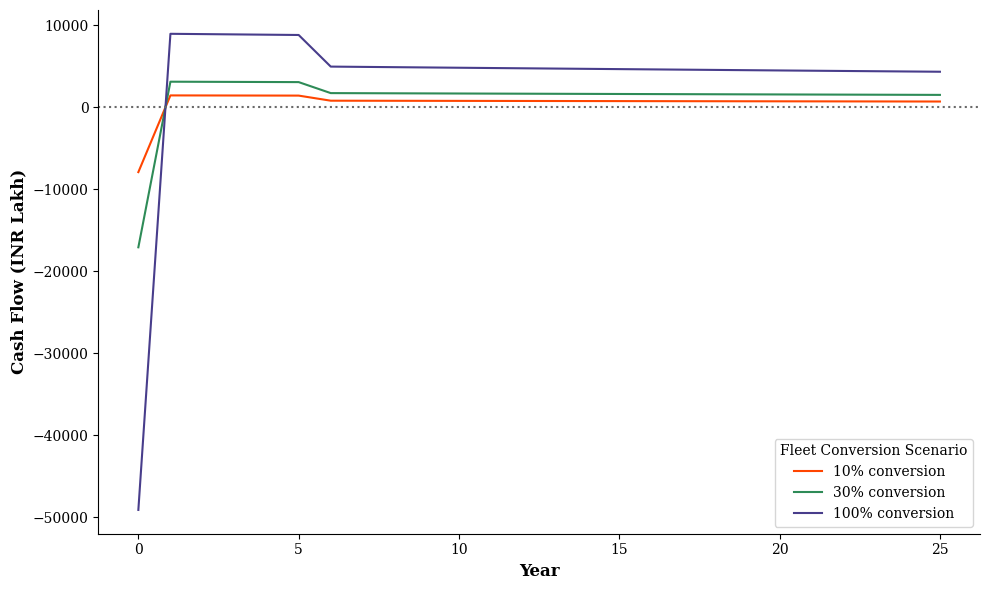

In [107]:
# Extract the columns for annual cashflows for all blocks and convert to INR Lakh
cashflows_10pct = block_pv_compiled_10pct[['year', 'cashflow_Rs6.00']]
cashflows_10pct['cashflow_Rs6.00'] = cashflows_10pct['cashflow_Rs6.00'] * usd_to_inr / 1000
cashflows_30pct = block_pv_compiled_30pct[['year', 'cashflow_Rs6.00']]
cashflows_30pct['cashflow_Rs6.00'] = cashflows_30pct['cashflow_Rs6.00'] * usd_to_inr / 1000
cashflows_100pct = block_pv_compiled_100pct[['year', 'cashflow_Rs6.00']]
cashflows_100pct['cashflow_Rs6.00'] = cashflows_100pct['cashflow_Rs6.00'] * usd_to_inr / 1000

# Summarize across columns (axis=1) to get stats per year
mean_10pct = np.mean(cashflows_10pct, axis=1)
mean_30pct = np.mean(cashflows_30pct, axis=1)
mean_100pct = np.mean(cashflows_100pct, axis=1)

# p10 = np.percentile(cashflows_100pct, 10, axis=1)
# p90 = np.percentile(cashflows_100pct, 90, axis=1)

# Generate x-axis: 25 years
years = cashflows_10pct['year']

# Plot the results
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(years, mean_10pct, color='orangered', label="10% conversion")
ax.plot(years, mean_30pct, color='seagreen', label="30% conversion")
ax.plot(years, mean_100pct, color='darkslateblue', label="100% conversion")

# Plot horizontal line
ax.axhline(0, color='dimgray', linestyle=':')

# plt.plot(years, median, label='Median', color='black')
# plt.fill_between(years, p10, p90, color='blue', alpha=0.2, label='10th–90th Percentile')
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Cash Flow (INR Lakh)', fontsize=12, fontweight='bold')
ax.legend(title='Fleet Conversion Scenario')

# Define the border around the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

# Customize the plot
plt.tight_layout()
plt.show()

In [ ]:
# Read in the economic results WITH subsidy implementation for all blocks
block_results_10pct = pd.read_csv('../data/processed/west-bengal-pv-economics-subs-ra-10pct.csv', index_col=False)
block_results_10pct = block_results_10pct.rename(columns={'district':'block'})
block_results_30pct = pd.read_csv('../data/processed/west-bengal-pv-economics-subs-ra-30pct.csv', index_col=False)
block_results_30pct = block_results_30pct.rename(columns={'district':'block'})
block_results_100pct = pd.read_csv('../data/processed/west-bengal-pv-economics-subs-ra-100pct.csv', index_col=False)
block_results_100pct = block_results_100pct.rename(columns={'district':'block'})

# Compile all the results into a dictionary
block_economics_all = {
    '10%': block_results_10pct,
    '30%': block_results_30pct,
    '100%': block_results_100pct
}

# Read in excel of West Bengal blocks names associated with each district
blocks_in_districts = pd.read_csv('../data/raw/wb-districts-blocks.csv')
# Create a dictionary for mapping blocks to districts
blocks_in_districts_dict = blocks_in_districts.groupby('district')['block'].apply(list).to_dict()
# Define a function to map block names to a district
def map_block_to_district(block_name):
    for district, blocks in blocks_in_districts_dict.items():
        if block_name in blocks:
            return district
    return None  # Return None if block is not found
# Map the blocks to their associated districts in each of the scenario dataframes
for scenario, df in block_economics_all.items():
    df['district'] = df['block'].apply(map_block_to_district)

# Write out the results for all tariffs and discount rates for all fleet conversion scenarios
for subsidy, df in block_economics_all.items():
    output_path = f"../data/processed/west-bengal-pv-economics-subs-ra-{subsidy.replace('%', 'pct')}.csv"
    df.reset_index().to_csv(output_path, index=False)
    print(f"Wrote {output_path}")

Wrote ../_Data/_processed/west-bengal-pv-economics-subs-ra-10pct.csv
Wrote ../_Data/_processed/west-bengal-pv-economics-subs-ra-30pct.csv
Wrote ../_Data/_processed/west-bengal-pv-economics-subs-ra-100pct.csv


In [ ]:
# Read in the economic results WITH subsidy implementation for all blocks and compile into dictionary
block_results_10pct = pd.read_csv('../data/processed/west-bengal-pv-economics-subs-ra-10pct.csv', index_col=False).drop(columns=['index'])
block_results_30pct = pd.read_csv('../data/processed/west-bengal-pv-economics-subs-ra-30pct.csv', index_col=False).drop(columns=['index'])
block_results_100pct = pd.read_csv('../data/processed/west-bengal-pv-economics-subs-ra-100pct.csv', index_col=False).drop(columns=['index'])

# Read in West Bengal district data
wb_districts = gpd.read_file('../data/processed/west-bengal-districts.geojson')
# Normalize district names (remove any whitespace, ensure capitalization)
wb_districts['district'] = wb_districts['district'].str.strip().str.title()

# Create a quick lookup dictionary for district -> code
district_code_map = wb_districts.set_index('district')['code'].to_dict()

# Function to load a single scenario dataframe and add districtcodes
def block_results(scenario: str) -> pd.DataFrame:
    """
    Reads in a scenario CSV, cleans it, and adds district codes.
    """
    path = f'../data/processed/west-bengal-pv-economics-subs-ra-{scenario.lower()}pct.csv'
    
    df = (
        pd.read_csv(path, index_col=False)
        .drop(columns=['index'], errors='ignore')  # safely drop if exists
    )

    # Normalize district names for matching
    df['district'] = df['district'].str.strip().str.title()

    # Map district codes directly
    df['code'] = df['district'].map(district_code_map)

    # Optional: check for missing matches
    missing = df.loc[df['code'].isna(), 'district'].unique()
    if len(missing) > 0:
        print(f"{scenario}: Missing district codes for {len(missing)} district(s): {missing}")

    return df

# Define the scenario names
scenarios = ['10', '30', '100']
block_economics_risk_adj = {f"{s}%": block_results(s) for s in scenarios}

# # Compile all the results into a dictionary
# block_economics_risk_adj = {
#     '10%': block_results_10pct,
#     '30%': block_results_30pct,
#     '100%': block_results_100pct
# }

# # Add district codes for all blocks
# for scenario, df in block_economics_risk_adj.items():
#     # Create a new copy of the dataframe
#     df_new = df.copy()
#     df_new = df_new.merge(
#         wb_districts[['district', 'code']],
#         on='district',
#         how='left')
    
#     # Add updated dataframe to dictionary
#     block_economics_risk_adj[scenario] = df_new

In [4]:
block_economics_risk_adj['10%']

,block,tariff_usd,tariff_inr,discount_rate,npv,lcoe,irr,payback_period,district,code
0,Bankura-I,0.035059,3.00,0.081158,-224514.737952,4.147277,0.044494,13.580646,Bankura,BN
1,Bankura-I,0.035293,3.02,0.081158,-220600.865865,4.147277,0.045179,13.470259,Bankura,BN
2,Bankura-I,0.035526,3.04,0.081158,-216686.993779,4.147277,0.045862,13.361448,Bankura,BN
3,Bankura-I,0.035760,3.06,0.081158,-212773.121692,4.147277,0.046543,13.254181,Bankura,BN
4,Bankura-I,0.035994,3.08,0.081158,-208859.249605,4.147277,0.047222,13.148425,Bankura,BN
...,...,...,...,...,...,...,...,...,...,...
136795,Sankrail-J,0.127381,10.90,0.081158,910254.947823,4.063611,0.278777,3.245965,Jhargram,JH
136796,Sankrail-J,0.127615,10.92,0.081158,912917.917820,4.063611,0.279380,3.240153,Jhargram,JH
136797,Sankrail-J,0.127849,10.94,0.081158,915580.887817,4.063611,0.279983,3.234357,Jhargram,JH
136798,Sankrail-J,0.128082,10.96,0.081158,918243.857814,4.063611,0.280587,3.228576,Jhargram,JH


In [5]:
# Define a function to extract relevant data for specified tariff and/or discount rate
def economics_filter(dict_economics, tariff, discount):
    """
    Extract relevant data for a specified tariff and optional discount rate.

    Parameters
    ----------
    dict_economics : dict
        Dictionary with scenario names as keys and DataFrames as values.
    tariff : float
        Tariff value in INR to filter on.
    discount : float, optional
        Discount rate to filter on. If None, all rates or singular rate is considered.

    Returns
    -------
    tariff_filter : dict
        DataFrames filtered for the given tariff (and excluding Kolkata if discount is None).
    tariff_discount_filter : dict
        DataFrames filtered for both the given tariff and nearest discount (excluding Kolkata if discount is given).
    """

    # Initialize the dictionaries to store the results for each scenario
    tariff_economics = {}
    tariff_filter = {}
    tariff_discount = {}
    tariff_discount_filter = {}

    # Extract the data for each scenario for 
    for scenario, df in dict_economics.items():
        # Filter datafraeme based on specified tariff
        df_tariff = df[np.isclose(df['tariff_inr'], tariff)]

        # Append the data into the new dictionary
        tariff_economics[scenario] = df_tariff

        # Skip if there is no matching tariff data
        if df_tariff.empty:
            print(f"No matching tariff data found for {scenario}.")
            continue

        if discount is not None:
            # Find the nearest available discount rate in this scenario
            nearest_rate = df_tariff['discount_rate'].iloc[
                (df_tariff['discount_rate'] - discount).abs().argsort()].iloc[0]
            print(f"Nearest available discount rate for {scenario}: {nearest_rate:.3f}")

            # Filter using the nearest available rate
            df_discount_filter = df_tariff[np.isclose(df_tariff['discount_rate'], nearest_rate)]

            # Append the data into the new dictionary
            tariff_discount[scenario] = df_discount_filter

            # Print the NPV, LCOE for Kolkata for the given scenario
            df_kol = df_discount_filter[df_discount_filter['district'] == 'Kolkata']
            if not df_kol.empty:
                npv_kol = df_kol['npv'].iloc[0]
                lcoe_kol = df_kol['lcoe'].iloc[0]
                print(f'Kolkata NPV for {scenario} conversion with discount rate {nearest_rate * 100:.3f}%: INR {(npv_kol / 1e5):.3f} Lakh')
                print(f'Kolkata LCOE for {scenario} conversion with discount rate {nearest_rate * 100:.3f}%: {lcoe_kol:.3f} INR/kWh')
            else:
                print(f"Kolkata not found for {scenario} at discount rate {nearest_rate:.3f}")

            # Remove Kolkata from each scenario and append it to new dictionary
            tariff_discount_filter[scenario] = df_discount_filter[df_discount_filter['district'] != 'Kolkata'].reset_index(drop=True)

        else:
            df_kol = df_tariff[df_tariff['district'] == 'Kolkata']
            if not df_kol.empty:
                npv_kol = df_kol['npv'].iloc[0]
                lcoe_kol = df_kol['lcoe'].iloc[0]
                print(f'Kolkata NPV for {scenario} conversion (all discount rates): INR {(npv_kol / 1e5):.3f}')
                print(f'Kolkata LCOE for {scenario} conversion (all discount rates): {lcoe_kol:.3f} INR/kWh')

            # Remove Kolkata and append it new dictionary
            tariff_filter[scenario] = df_tariff[df_tariff['district'] != 'Kolkata'].resest_index(drop=True)

    return tariff_filter, tariff_discount_filter, tariff_discount

In [10]:
policy_tariff_filter, policy_tariff_RAD_filter, policy_tariff_RAD = economics_filter(
    block_economics_risk_adj, 
    tariff=6.00, 
    discount=discount_rate_RA)

Nearest available discount rate for 10%: 0.081
Kolkata NPV for 10% conversion with discount rate 8.116%: INR 479.299 Lakh
Kolkata LCOE for 10% conversion with discount rate 8.116%: 5.521 INR/kWh
Nearest available discount rate for 30%: 0.081
Kolkata NPV for 30% conversion with discount rate 8.116%: INR 739.194 Lakh
Kolkata LCOE for 30% conversion with discount rate 8.116%: 5.719 INR/kWh
Nearest available discount rate for 100%: 0.081
Kolkata NPV for 100% conversion with discount rate 8.116%: INR 1650.800 Lakh
Kolkata LCOE for 100% conversion with discount rate 8.116%: 5.802 INR/kWh


In [ ]:
# Extract the results for each conversion scenario for WBEVP tariff (INR 6.00/kWh)
policy_tariff = 6.00

# Define an empty dictionary to store the results
policy_tariff_economics = {}

for scenario, df in block_economics_all.items():
    policy_tariff_economics[scenario] = df[np.isclose(df['tariff_inr'], policy_tariff)]

# Further extract the rows for the established discount rate 
# (7.00% discount rate per interpolation based on Government Securities Market yield rates for GS 2040 and GS 2055)
discount_rate = 0.07

policy_tariff_discount_all = {}
policy_tariff_discount_filter = {}

for scenario, df in policy_tariff_economics.items():
    # Find the nearest available discount rate in this scenario
    nearest_rate = df['discount_rate'].iloc[(df['discount_rate'] - discount_rate).abs().argsort()].iloc[0]
    # nearest_rate = df.loc[(df['discount_rate'] - discount_rate).abs().idxmin(), 'discount_rate']

    print(f"Nearest available discount rate for {scenario}: {nearest_rate:.3f}")
    
    # Filter using the nearest available rate
    df_discount = df[np.isclose(df['discount_rate'], nearest_rate)]

    # Filter for the given discount rate
    policy_tariff_discount_all[scenario] = df_discount[np.isclose(df_discount['discount_rate'], discount_rate)]

    # Print the NPV, LCOE for Kolkata for the given scenario
    df_kol = df_discount[df_discount['district'] == 'Kolkata']
    # df_kol = policy_tariff_discount[scenario][policy_tariff_discount[scenario]['district'] == 'Kolkata']
    npv_kol = df_kol['npv'].iloc[0]
    lcoe_kol = df_kol['lcoe'].iloc[0]
    print(f'Kolkata NPV for {scenario} conversion with discount rate {discount_rate}: INR {(npv_kol / 1e5):.3f}')
    print(f'Kolkata LCOE for {scenario} conversion with discount rate {discount_rate}: {lcoe_kol:.3f} INR/kWh')

    # Further filter out Kolkata to remove skewing for plotting
    df_filter = df_discount.copy()
    df_filter = df_filter[df_filter['district'] != 'Kolkata']

    policy_tariff_discount_filter[scenario] = df_filter

Nearest available discount rate for 10%: 0.070
Kolkata NPV for 10% conversion: INR 2291.733
Kolkata LCOE for 10% conversion: 3.897 INR/kWh
Nearest available discount rate for 30%: 0.070
Kolkata NPV for 30% conversion: INR 6035.359
Kolkata LCOE for 30% conversion: 3.898 INR/kWh
Nearest available discount rate for 100%: 0.070
Kolkata NPV for 100% conversion: INR 19141.207
Kolkata LCOE for 100% conversion: 3.898 INR/kWh


In [ ]:
# Read in the geometric data for West Bengal blocks, district boundaries
wb_blocks = gpd.read_file('../data/processed/west-bengal-blocks-districts.geojson')

# Create GeoJSON files by merging with block geometry data
for scenario, df in policy_tariff_RAD.items():
    # Merge only the needed columns to avoid duplicates
    gdf = df.merge(
        wb_blocks[['block', 'geometry']],
        on='block',
        how='left'
    )

    # Convert to GeoDataFrame with proper CRS
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=wb_blocks.crs)

    # --- Quality check for duplicate column names ---
    dup_cols = [col for col in gdf.columns if col.endswith('_x') or col.endswith('_y')]
    if dup_cols:
        print(f"Warning: Duplicate suffix columns found in {scenario}: {dup_cols}")
        # Optional: automatically clean up, e.g. drop them or rename them
        # gdf = gdf.drop(columns=dup_cols)
        # OR raise an error to stop execution
        raise ValueError(f"Duplicate columns found: {dup_cols}")
    else:
        print(f"No duplicate columns in {scenario}")

    # Write GeoJSON
    output_path = f"../data/processed/block-lcoe-wbevp-risk-{scenario.replace('%', 'pct')}.geojson"
    gdf.to_file(output_path, driver="GeoJSON")
    print(f"Wrote {output_path}")


No duplicate columns in 10%
Wrote ../_Data/_processed/block-lcoe-wbevp-risk-10pct.geojson
No duplicate columns in 30%
Wrote ../_Data/_processed/block-lcoe-wbevp-risk-30pct.geojson
No duplicate columns in 100%
Wrote ../_Data/_processed/block-lcoe-wbevp-risk-100pct.geojson


In [12]:
# Calculate the average payback period across all blocks for a policy tariff of INR 6.00/kWh and for a risk-adjusted discount rate
for scenario, df in policy_tariff_RAD.items():
    # Calculate the min, max, and average payback periods for each scenario
    mean_payback = df['payback_period'].mean()
    min_payback = df['payback_period'].min()
    max_payback = df['payback_period'].max()

    # Print the results
    print(f'Average payback period for {scenario} conversion: {mean_payback:.2f}')
    print(f'Minimum payback period for {scenario} conversion: {min_payback:.2f}')
    print(f'Maximum payback period for {scenario} conversion: {max_payback:.2f}')
    print('')

Average payback period for 10% conversion: 5.87
Minimum payback period for 10% conversion: 5.57
Maximum payback period for 10% conversion: 9.17

Average payback period for 30% conversion: 5.88
Minimum payback period for 30% conversion: 5.57
Maximum payback period for 30% conversion: 9.68

Average payback period for 100% conversion: 5.92
Minimum payback period for 100% conversion: 5.57
Maximum payback period for 100% conversion: 9.89



In [ ]:
policy_tariff_RAD_filter['30%'].loc[policy_tariff_RAD_filter['30%']['district'] == 'Alipurduar']

,block,tariff_usd,tariff_inr,discount_rate,npv,lcoe,irr,payback_period,district,code
34,Alipurduar-I,0.070118,6.0,0.081158,1.037050e+07,4.444182,0.123218,6.325848,Alipurduar,AD
35,Alipurduar-Ii,0.070118,6.0,0.081158,8.168541e+06,4.444182,0.123218,6.325848,Alipurduar,AD
36,Falakata,0.070118,6.0,0.081158,1.792344e+07,4.444182,0.123218,6.325848,Alipurduar,AD
37,Kalchini,0.070118,6.0,0.081158,1.910728e+07,4.444182,0.123218,6.325848,Alipurduar,AD
38,Kumargram,0.070118,6.0,0.081158,9.162972e+06,4.444182,0.123218,6.325848,Alipurduar,AD
39,Madarihat,0.070118,6.0,0.081158,1.167273e+07,4.444182,0.123218,6.325848,Alipurduar,AD


In [71]:
policy_tariff_RAD['30%'].loc[
    policy_tariff_RAD['30%']['lcoe'].nlargest(5).index
]

,block,tariff_usd,tariff_inr,discount_rate,npv,lcoe,irr,payback_period,district,code
91750,Kolkata,0.070118,6.0,0.081158,7.391940e+07,5.719444,0.087949,9.681561,Kolkata,KO
41750,Barrackpur-Ii,0.070118,6.0,0.081158,4.067404e+07,5.317311,0.098349,8.649010,North Twenty Four Parganas,PN
41350,Rajarhat,0.070118,6.0,0.081158,3.679295e+07,4.898113,0.110100,7.586903,North Twenty Four Parganas,PN
14950,Kalchini,0.070118,6.0,0.081158,1.910728e+07,4.444182,0.123218,6.325848,Alipurduar,AD
15750,Madarihat,0.070118,6.0,0.081158,1.167273e+07,4.444182,0.123218,6.325848,Alipurduar,AD


In [70]:
policy_tariff_RAD_filter['30%'].loc[
    policy_tariff_RAD_filter['30%']['lcoe'].nsmallest(5).index
]

,block,tariff_usd,tariff_inr,discount_rate,npv,lcoe,irr,payback_period,district,code
245,Purulia-Ii,0.070118,6.0,0.081158,3.081777e+06,4.012613,0.140041,5.568642,Puruliya,PU
247,Raghunathpur-Ii,0.070118,6.0,0.081158,7.704443e+05,4.012613,0.140041,5.568642,Puruliya,PU
248,Santuri,0.070118,6.0,0.081158,6.364540e+05,4.012613,0.140041,5.568642,Puruliya,PU
231,Balarampur,0.070118,6.0,0.081158,1.138918e+06,4.012613,0.140041,5.568642,Puruliya,PU
241,Neturia,0.070118,6.0,0.081158,1.138918e+06,4.012613,0.140041,5.568642,Puruliya,PU


In [32]:
policy_tariff_RAD_filter['10%'].sort_values('npv').head(15)

,block,tariff_usd,tariff_inr,discount_rate,npv,lcoe,irr,payback_period,district,code
17,Sarenga,0.070118,6.0,0.081158,241710.716697,4.147277,0.134438,5.803529,Bankura,BN
14,Raipur-I,0.070118,6.0,0.081158,241710.716697,4.147277,0.134438,5.803529,Bankura,BN
18,Simlapal,0.070118,6.0,0.081158,241710.716697,4.147277,0.134438,5.803529,Bankura,BN
11,Mejhia,0.070118,6.0,0.081158,241710.716697,4.147277,0.134438,5.803529,Bankura,BN
9,Khatra-I,0.070118,6.0,0.081158,241710.716697,4.147277,0.134438,5.803529,Bankura,BN
5,Hirbandh,0.070118,6.0,0.081158,241710.716697,4.147277,0.134438,5.803529,Bankura,BN
177,Ausgram-I,0.070118,6.0,0.081158,241710.716697,4.147277,0.134438,5.803529,Barddhaman,BR
7,Indus,0.070118,6.0,0.081158,241710.716697,4.147277,0.134438,5.803529,Bankura,BN
15,Ranibundh,0.070118,6.0,0.081158,241710.716697,4.147277,0.134438,5.803529,Bankura,BN
340,Sankrail-J,0.070118,6.0,0.081158,257827.298517,4.063611,0.137878,5.657524,Jhargram,JH


In [33]:
policy_tariff_RAD_filter['10%'].sort_values('npv', ascending=False).head(15)

,block,tariff_usd,tariff_inr,discount_rate,npv,lcoe,irr,payback_period,district,code
104,Barrackpur-Ii,0.070118,6.0,0.081158,3.491327e+07,4.313970,0.128124,6.119562,North Twenty Four Parganas,PN
285,Asansol,0.070118,6.0,0.081158,2.531280e+07,4.155209,0.134119,5.817384,Paschim Barddhaman,BR
103,Rajarhat,0.070118,6.0,0.081158,1.997333e+07,4.281893,0.129171,6.039214,North Twenty Four Parganas,PN
37,Kalchini,0.070118,6.0,0.081158,1.489279e+07,4.444182,0.123218,6.325848,Alipurduar,AD
36,Falakata,0.070118,6.0,0.081158,1.399307e+07,4.444182,0.123218,6.325848,Alipurduar,AD
327,Jalpaiguri,0.070118,6.0,0.081158,1.267398e+07,4.320328,0.127724,6.107017,Jalpaiguri,JP
276,Krishnagar-I,0.070118,6.0,0.081158,1.248804e+07,4.146279,0.134479,5.801787,Nadia,NA
129,Berhampore,0.070118,6.0,0.081158,1.196787e+07,4.188048,0.132809,5.874763,Murshidabad,MU
23,Cooch Behar-I,0.070118,6.0,0.081158,1.011187e+07,4.318562,0.127790,6.103900,Koch Bihar,KB
298,Chinsurah-Magrah,0.070118,6.0,0.081158,9.613141e+06,4.242101,0.130695,5.969288,Hugli,HG


In [24]:
policy_tariff_RAD_filter['30%'].iloc[policy_tariff_RAD_filter['30%']['npv'].idxmin()]

block                     Mirik
tariff_usd             0.070118
tariff_inr                  6.0
discount_rate          0.081158
npv               344686.649029
lcoe                   4.310242
irr                    0.128101
payback_period          6.08922
district              Darjiling
code                         DA
Name: 254, dtype: object

In [27]:
policy_tariff_RAD_filter['100%'].iloc[policy_tariff_RAD_filter['100%']['npv'].idxmax()]

block                          Barrackpur-Ii
tariff_usd                          0.070118
tariff_inr                               6.0
discount_rate                       0.081158
npv                          60840259.934945
lcoe                                5.689042
irr                                 0.088703
payback_period                      9.597698
district          North Twenty Four Parganas
code                                      PN
Name: 104, dtype: object

In [37]:
policy_tariff_RAD_filter['30%'].groupby('district')['npv'].median().sort_values(ascending=False)

district
Alipurduar                    1.102161e+07
Jalpaiguri                    9.308278e+06
Koch Bihar                    8.716219e+06
North Twenty Four Parganas    7.422156e+06
Nadia                         6.485918e+06
South Twenty Four Parganas    5.006816e+06
Maldah                        4.990227e+06
Hugli                         4.820584e+06
Murshidabad                   4.272149e+06
Dakshin Dinajpur              3.473395e+06
Birbhum                       3.195591e+06
Paschim Barddhaman            3.002704e+06
Purba Medinipur               2.966782e+06
Uttar Dinajpur                2.888852e+06
Haora                         1.711199e+06
Barddhaman                    1.389837e+06
Paschim Medinipur             1.296301e+06
Puruliya                      1.138918e+06
Darjiling                     6.230874e+05
Bankura                       6.042768e+05
Jhargram                      5.478830e+05
Name: npv, dtype: float64

/var/folders/x0/qnl8p2f174g_y6029kr9p3q80000gn/T/ipykernel_7285/284920440.py:78: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(new_labels)


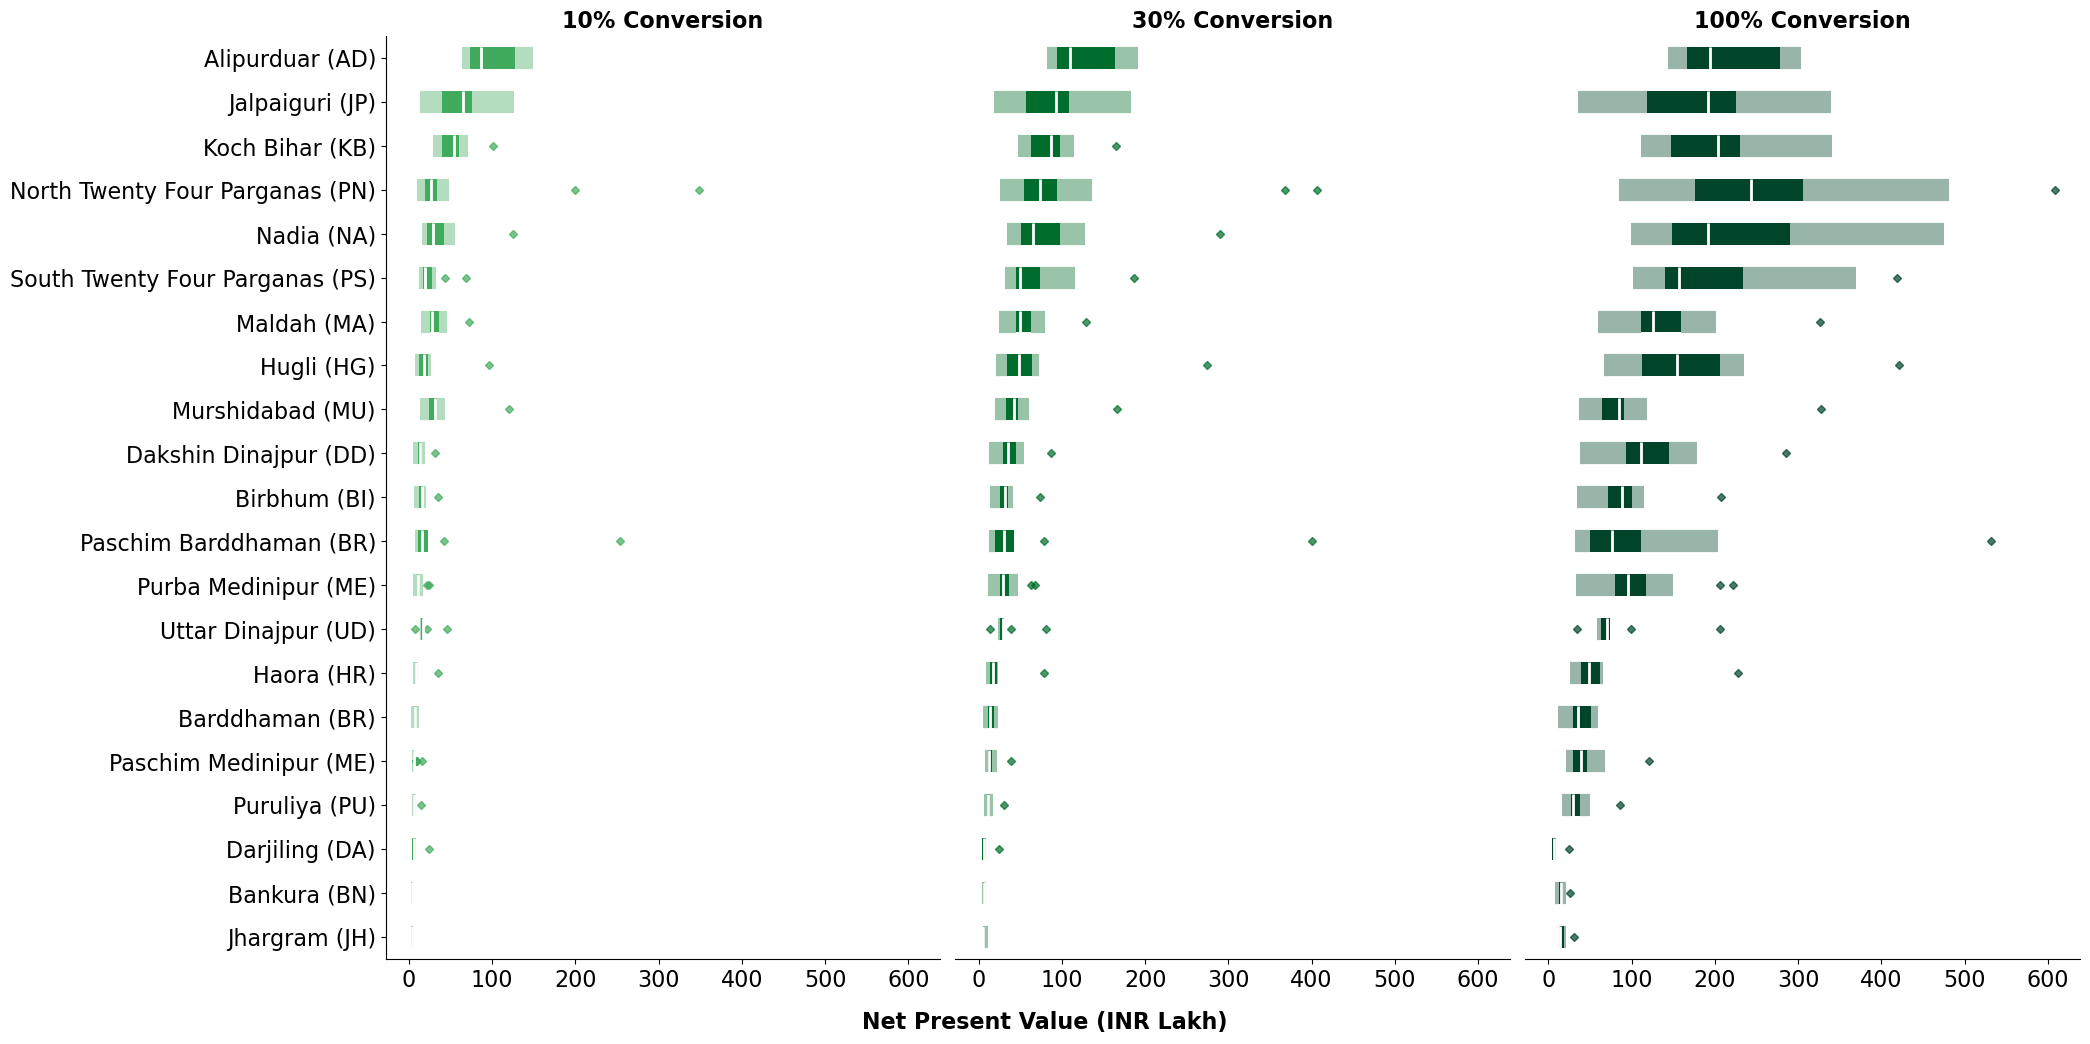

In [50]:
# Define the colors for each plot
scenario_colors = {
    '10%': '#41ab5d',
    '30%': '#006d2c',
    '100%': '#004529'
}

# Determine the order of districts (use one scenario or combined medians)
district_order = (
    policy_tariff_RAD_filter['30%'].groupby('district')['npv']
    .median()
    .sort_values(ascending=False)
    .index
)

# Create a single row of subplots
scenarios = list(policy_tariff_RAD_filter.keys())
n_scenarios = len(scenarios)

fig, axes = plt.subplots(
    1, n_scenarios,
    figsize=(7 * n_scenarios, len(district_order) * 0.5),
    sharey=True,
    sharex=True
)

# If only one scenario, axes is not iterable
if n_scenarios == 1:
    axes = [axes]

# Loop through scenarios and plot each in its own subplot
for ax, scenario in zip(axes, scenarios):
    df = policy_tariff_RAD_filter[scenario]

    # Plot the box-and-whisker plot
    sns.boxplot(
        data=df,
        y='district',
        x=df['npv'] / 1e5,
        order=district_order,
        orient='h',
        width=0.5,
        showfliers=True,
        color=scenario_colors[scenario],
        linewidth=0,
        boxprops=dict(facecolor=scenario_colors[scenario], alpha=1),
        whiskerprops=dict(color=scenario_colors[scenario], alpha=0.4, linewidth=16),
        capprops=dict(color=scenario_colors[scenario], linewidth=0),
        medianprops=dict(color='white', linewidth=2),
        flierprops=dict(
            marker='D',                          # diamond
            markerfacecolor=scenario_colors[scenario],
            markeredgecolor=scenario_colors[scenario],
            markersize=4.5,
            alpha=0.7
        ),
        ax=ax
    )

    ax.set_title(f'{scenario} Conversion', fontsize=16, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', which='major', labelsize=16)

    if ax == axes[0]:
        # Create a lookup table with both district and code
        df_labels = df[['district', 'code']].copy()

        # Create combined labels
        df_labels['district_label'] = df_labels['district'] + ' (' + df_labels['code'] + ')'

        # Use the district order to define label order
        label_map = df_labels.drop_duplicates(subset=['district']).set_index('district')['district_label']

        # Apply the labels in the correct order
        new_labels = [label_map.get(dist, dist) for dist in district_order]

        ax.set_yticklabels(new_labels)
    else:
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    # Hide y-axis labels and ticks for all but the first plot
    if ax != axes[0]:
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    # Clean up borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(ax == axes[0])  # only show y-axis on first plot

# Add a common x-axis label
fig.supxlabel('Net Present Value (INR Lakh)', fontsize=16, fontweight='bold')

# Tight layout and show
plt.tight_layout()
plt.show()

In [ ]:
# --- Perform a sensitivity analysis on how NPV and LCOE changes by varying charging tariff and discount rate ---

block_economics_30pct = block_economics_all['30%']

# Define the base tariff and base discount rates which which to compute percentage change
base_tariff = 6.00      # INR 6.00/kWh
base_discount = 0.070   # 7.00% discount rate

# Create an empty list to store the results of the sensitivity analysis
results_tariff = []
results_discount = []

for block, group in block_economics_30pct.groupby('block'):
    # Extract the data for the base tariff
    base_case = group[(np.isclose(group['tariff_inr'], base_tariff)) & 
                           (np.isclose(group['discount_rate'], base_discount))]
    # # Extract the data for the base discount
    # base_discount_df = group[np.isclose(group['discount_rate'], base_discount)]
    if base_case.empty:
        continue        # skip the block if base case values are missing or not available

    # Obtain the values for base case NPV and LCOE values
    base_case_npv = base_case['npv'].values[0]
    base_case_lcoe = base_case['lcoe'].values[0]
    # base_tariff_npv = base_tariff_df['npv'].values[0]
    # base_tariff_lcoe = base_tariff_df['lcoe'].values[0]
    # base_discount_npv = base_discount_df['npv'].values[0]
    # base_discount_lcoe = base_discount_df['lcoe'].values[0]

    # --- Fixed Discount Rate, Vary Charging Tariff ---
    # Create copy of dataframe subset with discount rate set at base discount rate
    sensitivity_tariff = group[np.isclose(group['discount_rate'], base_discount)].copy()

    # Compute the percentage change in NPV & LCOE for each block
    sensitivity_tariff['npv_pct_change'] = (sensitivity_tariff['npv'] - base_case_npv) / base_case_npv * 100
    sensitivity_tariff['lcoe_pct_change'] = (sensitivity_tariff['lcoe'] - base_case_lcoe) / base_case_lcoe * 100

    # Append the results to initialized list
    results_tariff.append(sensitivity_tariff[['block', 'tariff_inr', 'discount_rate', 'npv_pct_change', 'lcoe_pct_change']])

    # --- Fixed Charging Tariff, Vary Discount Rate ---
    # Create copy of dataframe subset with discount rate set at base discount rate
    sensitivity_discount = group[np.isclose(group['tariff_inr'], base_tariff)].copy()

    # Compute the percentage change in NPV & LCOE for each block
    sensitivity_discount['npv_pct_change'] = (sensitivity_discount['npv'] - base_case_npv) / base_case_npv * 100
    sensitivity_discount['lcoe_pct_change'] = (sensitivity_discount['lcoe'] - base_case_lcoe) / base_case_lcoe * 100

    # Append the results to initialized list
    results_discount.append(sensitivity_discount[['block', 'tariff_inr', 'discount_rate', 'npv_pct_change', 'lcoe_pct_change']])

# Create a dataframe for the final results
sensitivity_tariff_df = pd.concat(results_tariff)
sensitivity_discount_df = pd.concat(results_discount)

In [117]:
sensitivity_tariff_df

,block,tariff_inr,discount_rate,npv_pct_change,lcoe_pct_change
557614,Alipurduar-I,3.00,0.07,-154.158715,0.0
557655,Alipurduar-I,3.02,0.07,-153.130991,0.0
557696,Alipurduar-I,3.04,0.07,-152.103266,0.0
557737,Alipurduar-I,3.06,0.07,-151.075541,0.0
557778,Alipurduar-I,3.08,0.07,-150.047816,0.0
...,...,...,...,...,...
360609,Vishnupur,10.90,0.07,221.031237,0.0
360650,Vishnupur,10.92,0.07,221.933405,0.0
360691,Vishnupur,10.94,0.07,222.835573,0.0
360732,Vishnupur,10.96,0.07,223.737742,0.0


In [118]:
# Aggregate across all blocks
avg_tariff = sensitivity_tariff_df.groupby('tariff_inr')[
    ['npv_pct_change', 'lcoe_pct_change']].agg(['mean', 'std']).reset_index()
avg_discount = sensitivity_discount_df.groupby('discount_rate')[
    ['npv_pct_change', 'lcoe_pct_change']].agg(['mean', 'std']).reset_index()

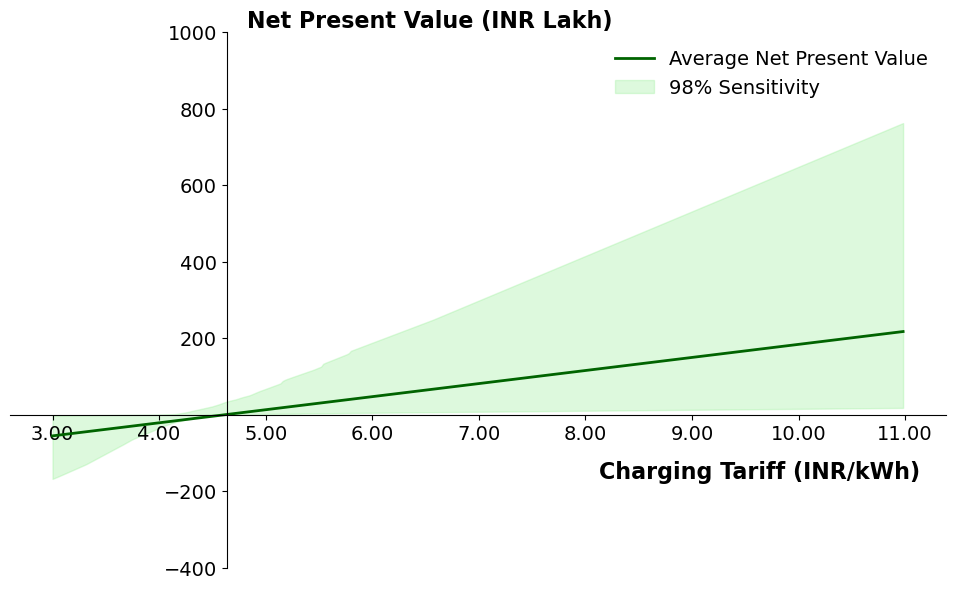

In [48]:
# Aggregate and determine the average NPV and LCOE across all blocks based on different charging tariffs
avg_npv_per_tariff = block_results_30pct.groupby('tariff_inr')[
    'npv'].agg(['mean', 'std']).reset_index()
avg_lcoe_per_tariff = block_results_30pct.groupby('tariff_inr')[
    'lcoe'].agg(['mean', 'std']).reset_index()

# Compute the quantile bounds (2% and 98%) to exclude the bottom 2% and top $ of NPV outliers
q05 = block_results_30pct.groupby('tariff_inr')['npv'].quantile(0.02)
q95 = block_results_30pct.groupby('tariff_inr')['npv'].quantile(0.98)

# Compute the sensitivity bands (min and max thresholds) on how NPV varies with respect to charging tariff
sensitivity_npv = block_results_30pct.groupby('tariff_inr')[
    'npv'].agg(['mean', 'min', 'max']).reset_index()

# Define the base policy tariff
base_tariff = 6.00

# Compute the tariff where mean NPV crosses zero (interpolated)
zero_npv_tariff = np.interp(
    0,                                                  # target mean NPV
    avg_npv_per_tariff['mean'].values / 1e5,                   # y-values (npv)
    avg_npv_per_tariff['tariff_inr'].values             # x-values (tariff)
)

# Plot sensitivity results
fig, ax = plt.subplots(figsize=(10,6))

# Plot the variation in NPV and LCOE with respect to altering charging tariff
ax.plot(avg_npv_per_tariff['tariff_inr'],
        avg_npv_per_tariff['mean'] / 1e5,
        linewidth=2, 
        color='darkgreen',
        label='Average Net Present Value')
ax.fill_between(
    avg_npv_per_tariff['tariff_inr'],
    q05 / 1e5,
    q95 / 1e5,
    alpha=0.3,
    color='lightgreen',
    label='98% Sensitivity'
)
# ax.plot(sensitivity_npv['tariff_inr'],
#         sensitivity_npv['min'] / 1e5,
#         linewidth=1, 
#         color='crimson',
#         linestyle = ':',
#         label='Minimum NPV')
# ax.plot(sensitivity_npv['tariff_inr'],
#         sensitivity_npv['max'] / 1e5,
#         linewidth=1, 
#         color='crimson',
#         linestyle=':',
#         label='Maximum NPV')

# ax.plot(avg_npv_lcoe_per_tariff['tariff_inr'], avg_tariff['lcoe']['mean'], 
#         linewidth=2, label='LCOE')

# Move axes (spines) to the middle
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', zero_npv_tariff))

# Hide the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set custom tick formatting (2 decimal places for tariff)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Get the default y-ticks
yticks = ax.get_yticks()

# Exclude 0
yticks = [y for y in yticks if y != 0]

# Apply the new ticks
ax.set_yticks(yticks)

# Remove built-in labels
ax.set_xlabel('')
ax.set_ylabel('')

# Add custom label at specific data coordinates
ax.text(0.63, 0.2, 'Charging Tariff (INR/kWh)',
        transform=ax.transAxes, 
        ha='left', va='top', fontsize=16, fontweight='bold')

ax.text(zero_npv_tariff + 1.9, max(yticks), 
        'Net Present Value (INR Lakh)', ha='center', va='bottom',
        fontsize=16, fontweight='bold', rotation=0)

# Increase font size of tick labels
ax.tick_params(axis='both', which='major', labelsize=14)

# Customize the plot
plt.legend(fontsize=14, loc='upper right', frameon=False)
plt.tight_layout()
plt.show()